In [1]:
from iChem.utils import load_smiles, binary_fps
from iChem.visualization import cluster_connect_vis, cluster_dendrogram, clusters_pop_isim_plot, clusters_pop_plot

/home/kenneth/Documents/iChem/iChem/bblean/similarity.py:101: UserWarning: C++ optimized similarity calculations not available, falling back to python implementation
  warnings.warn(


In [2]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

from iChem.bblean.bitbirch import BitBirch


In [3]:
smiles = load_smiles("/home/kenneth/Documents/iChem/tests/data/mcule_natural_products.smi")
#smiles = smiles[:25]
fps = binary_fps(smiles=smiles, fp_type="ECFP4", return_invalid=False)

In [4]:
model = BitBirch(threshold=0.3, branching_factor=2048, merge_criterion="diameter")
model.fit(fps)

BitBirch(threshold=0.3, branching_factor=2048, merge_criterion='diameter')

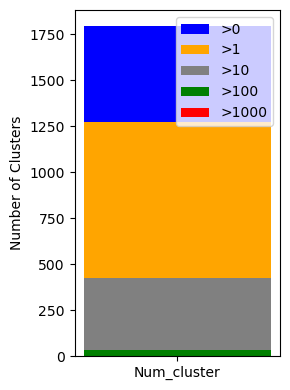

In [5]:
clusters_pop_plot(model)

/home/kenneth/Documents/iChem/iChem/bblean/bitbirch.py:917: RuntimeWarning: Invalid n_objects = 1 in isim. Expected n_objects >= 2
  return [jt_isim_from_sum(ls, n) for ls, n in zip(self.get_linear_sums(sort=sort), self.get_cluster_populations(sort=sort))]


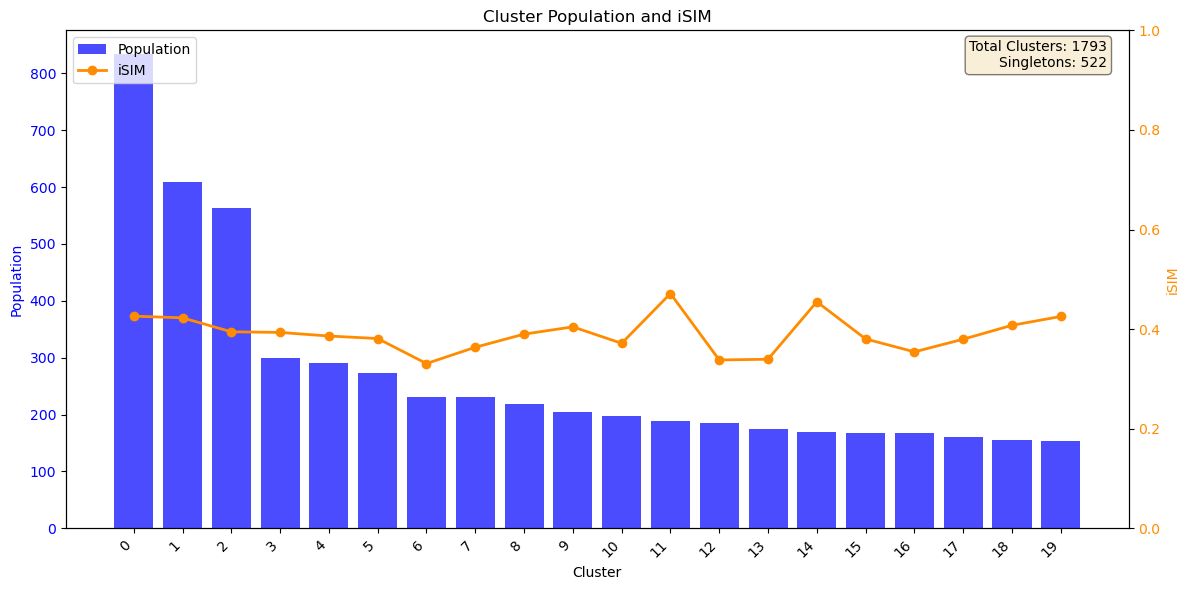

In [6]:
clusters_pop_isim_plot(model)

In [11]:
sim_matrix = jt_sim_matrix_packed(fps)
dist_matrix = 1 - sim_matrix

In [12]:
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform

# Get the condensed distance matrix (upper triangular form in 1D array)
condensed_dist_matrix = squareform(dist_matrix)


# Compute the linkage matrix directly
Z = linkage(condensed_dist_matrix,
            method="average")

{'icoord': [[25.0, 25.0, 35.0, 35.0],
  [65.0, 65.0, 75.0, 75.0],
  [55.0, 55.0, 70.0, 70.0],
  [45.0, 45.0, 62.5, 62.5],
  [85.0, 85.0, 95.0, 95.0],
  [135.0, 135.0, 145.0, 145.0],
  [125.0, 125.0, 140.0, 140.0],
  [115.0, 115.0, 132.5, 132.5],
  [155.0, 155.0, 165.0, 165.0],
  [123.75, 123.75, 160.0, 160.0],
  [105.0, 105.0, 141.875, 141.875],
  [90.0, 90.0, 123.4375, 123.4375],
  [185.0, 185.0, 195.0, 195.0],
  [175.0, 175.0, 190.0, 190.0],
  [215.0, 215.0, 225.0, 225.0],
  [235.0, 235.0, 245.0, 245.0],
  [220.0, 220.0, 240.0, 240.0],
  [205.0, 205.0, 230.0, 230.0],
  [182.5, 182.5, 217.5, 217.5],
  [106.71875, 106.71875, 200.0, 200.0],
  [53.75, 53.75, 153.359375, 153.359375],
  [30.0, 30.0, 103.5546875, 103.5546875],
  [15.0, 15.0, 66.77734375, 66.77734375],
  [5.0, 5.0, 40.888671875, 40.888671875]],
 'dcoord': [[0.0,
   np.float64(0.8933333333333333),
   np.float64(0.8933333333333333),
   0.0],
  [0.0, np.float64(0.7234042553191489), np.float64(0.7234042553191489), 0.0],
  [0.0,


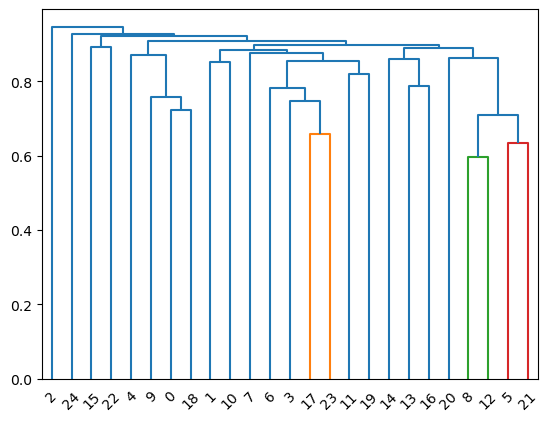

In [13]:
# Plot the dendrogram for the clustering using sklearn
dendrogram(Z)

In [16]:
cluster_dendrogram(smiles, min_size=0, steps = 4)

Step 0: Threshold = 0.308, Number of clusters = 21
Step 1: Threshold = 0.205, Number of clusters = 16
Step 2: Threshold = 0.103, Number of clusters = 2
Step 3: Threshold = 0.000, Number of clusters = 1


Step 0: Threshold = 0.308, Number of clusters = 21
Step 1: Threshold = 0.205, Number of clusters = 14
Step 2: Threshold = 0.103, Number of clusters = 4
Step 3: Threshold = 0.000, Number of clusters = 1
Saving cluster images to: /tmp/ichem_clusters_p33olawh



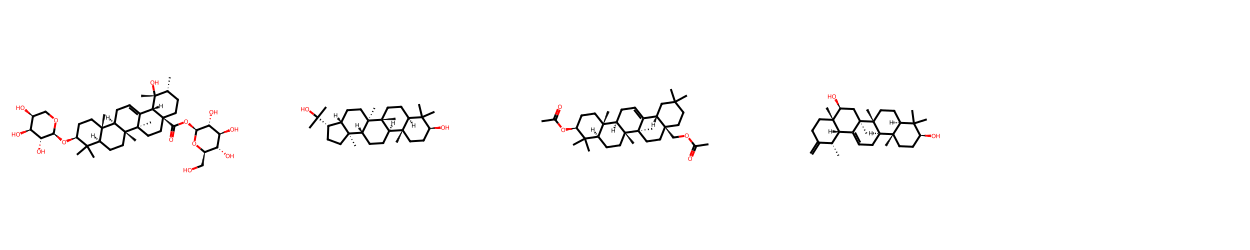
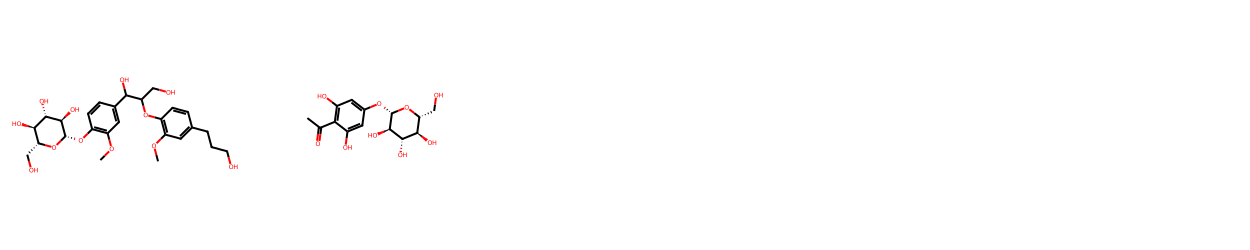
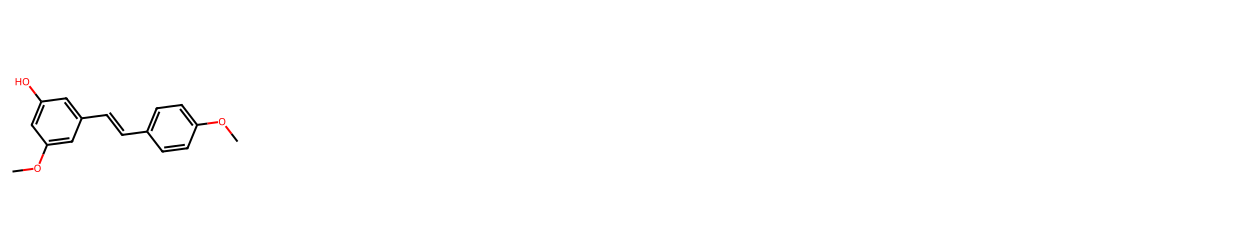
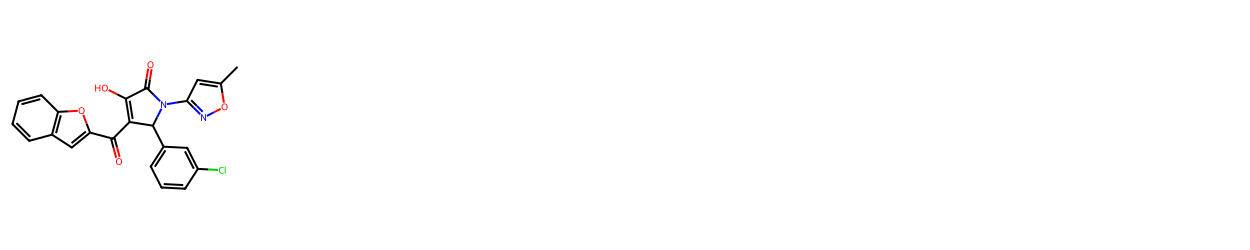
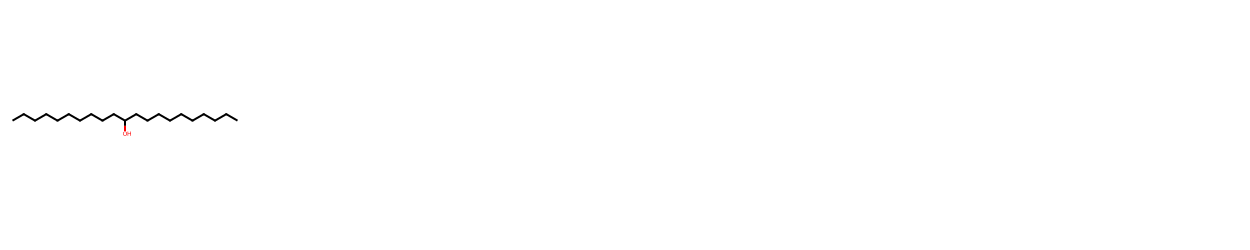
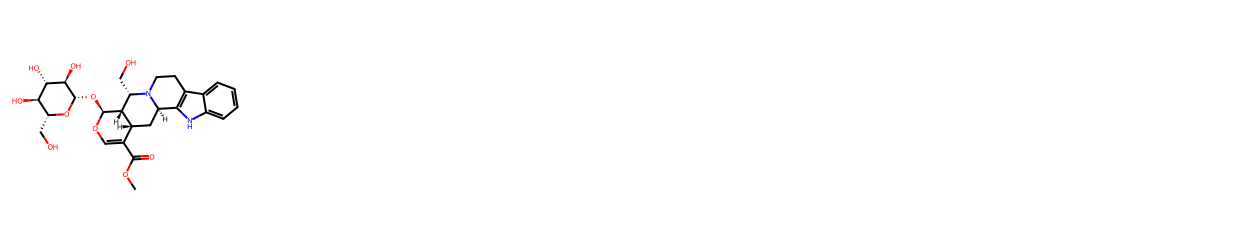
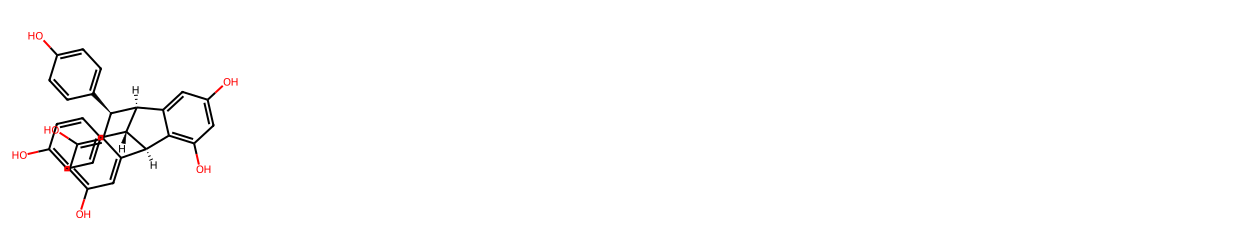
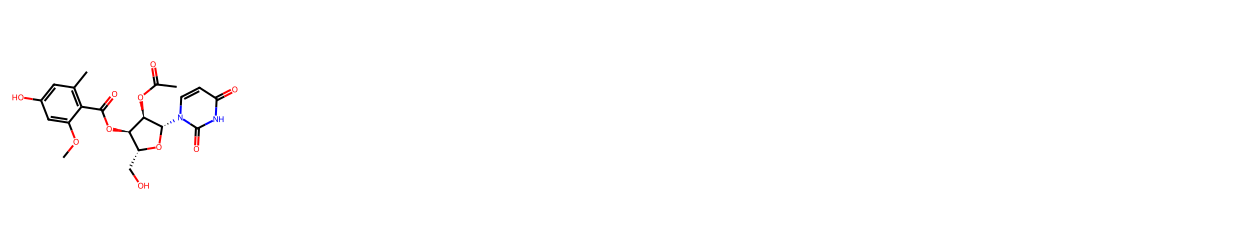
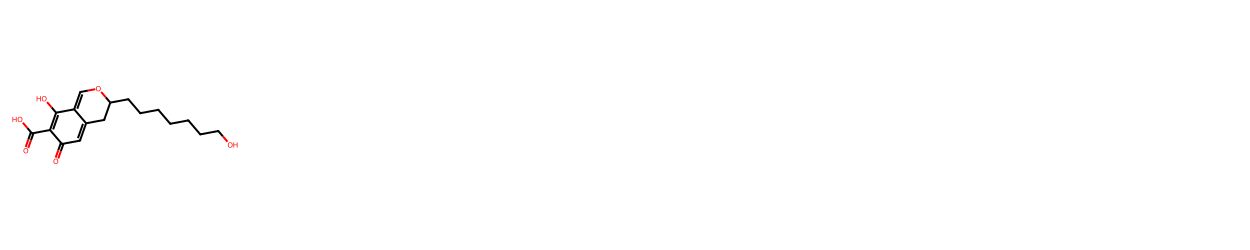
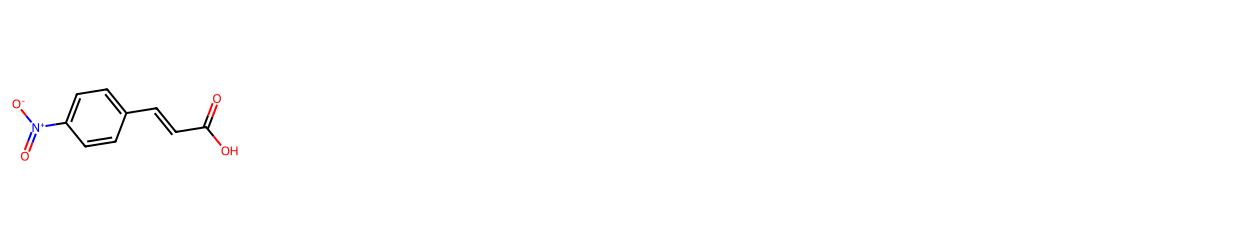
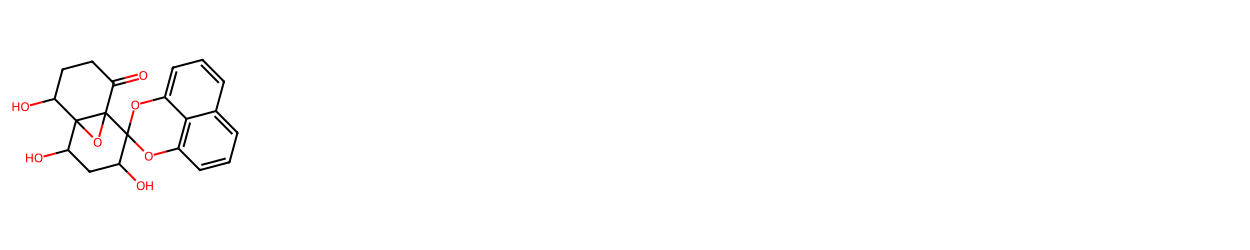
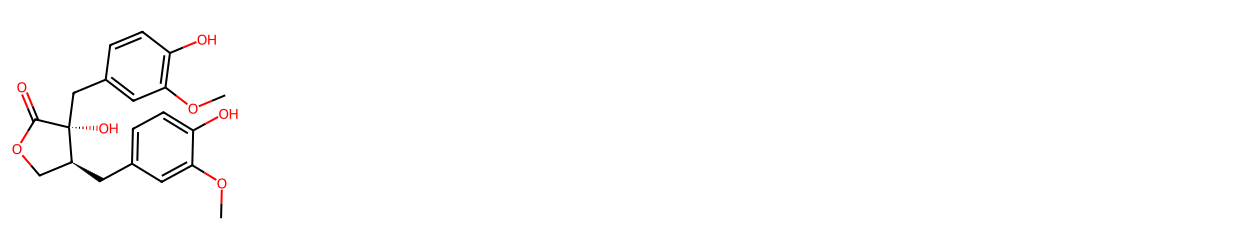
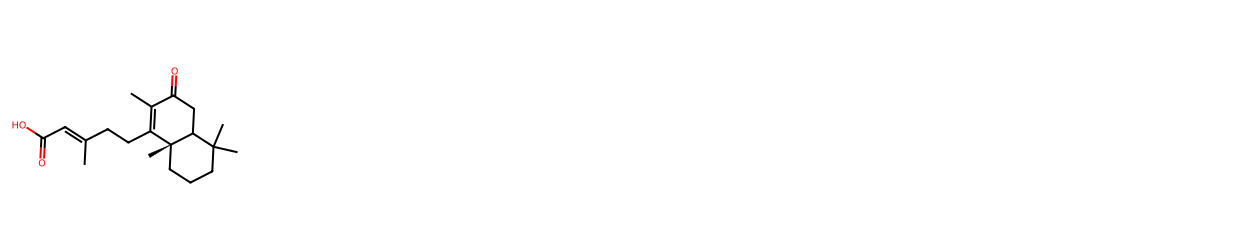
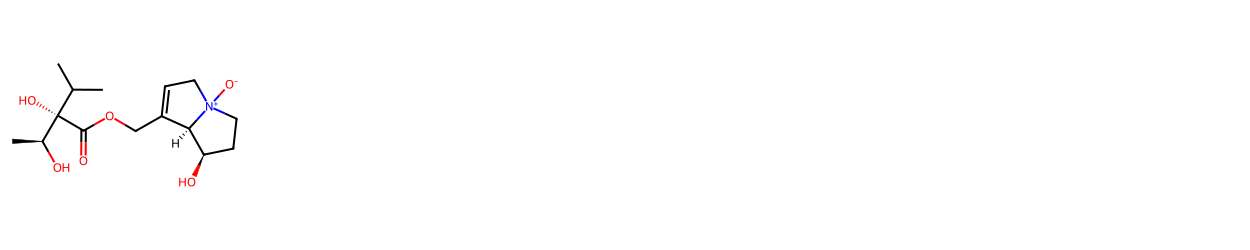
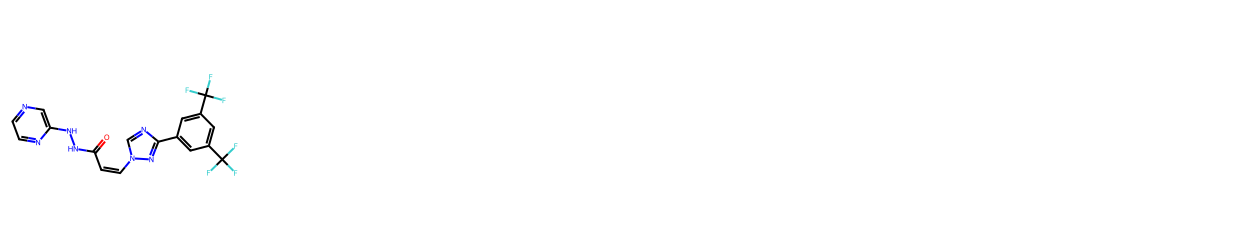
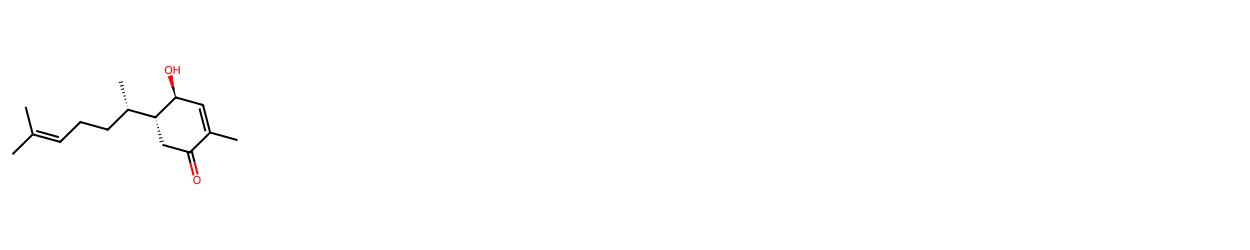
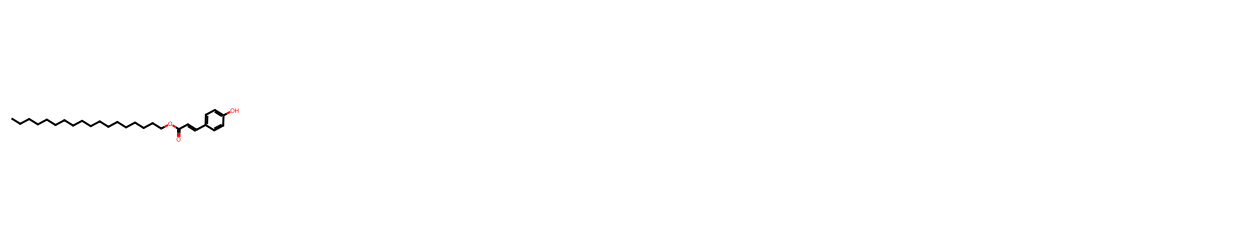
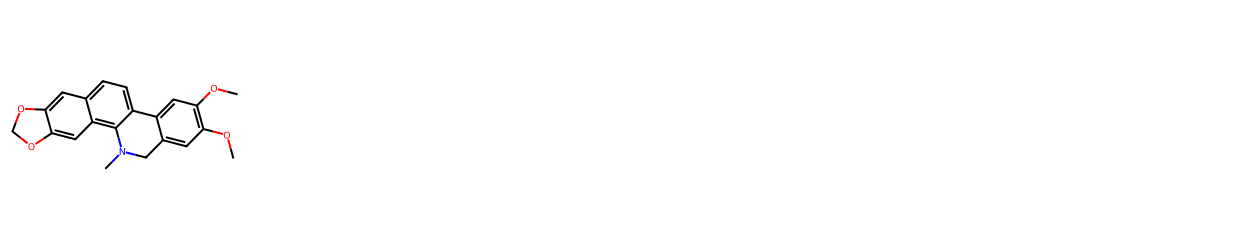
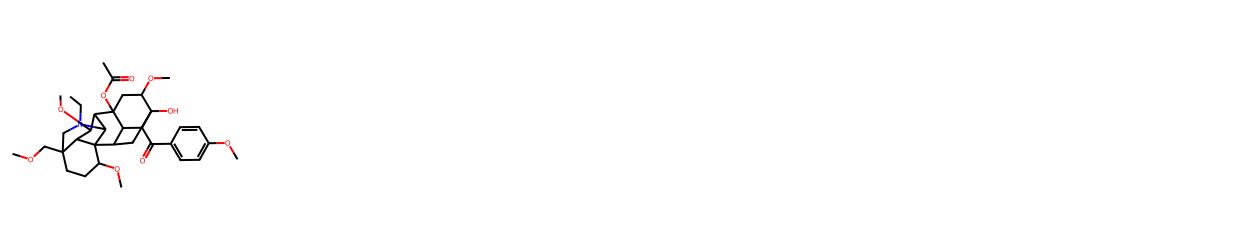
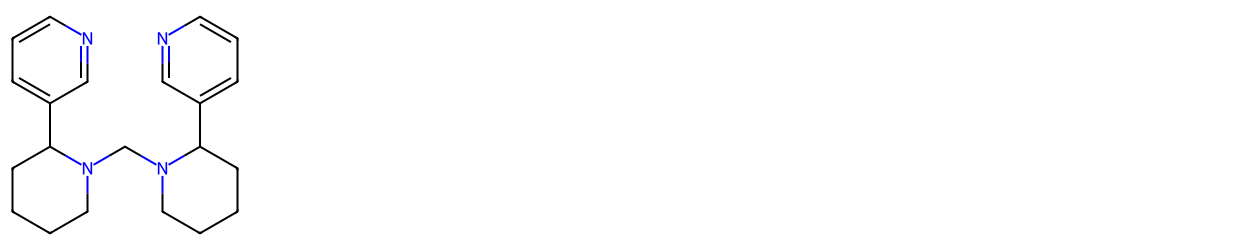
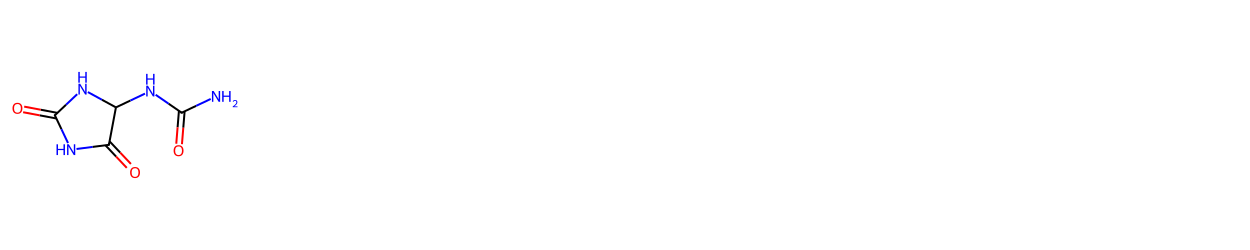
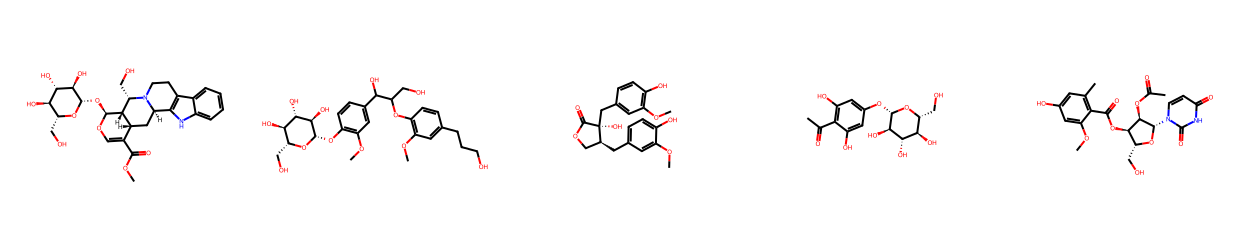
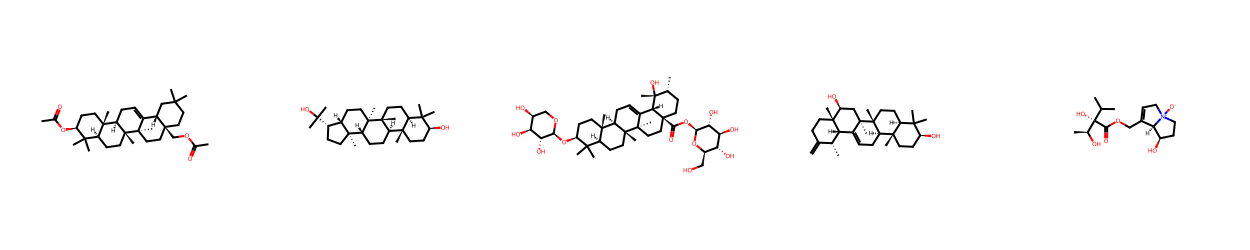
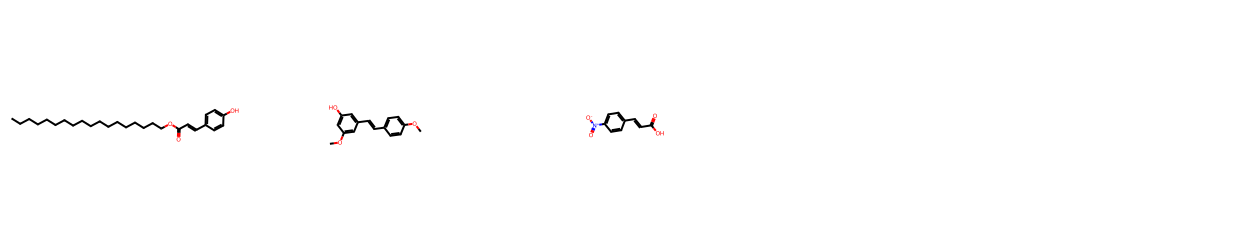
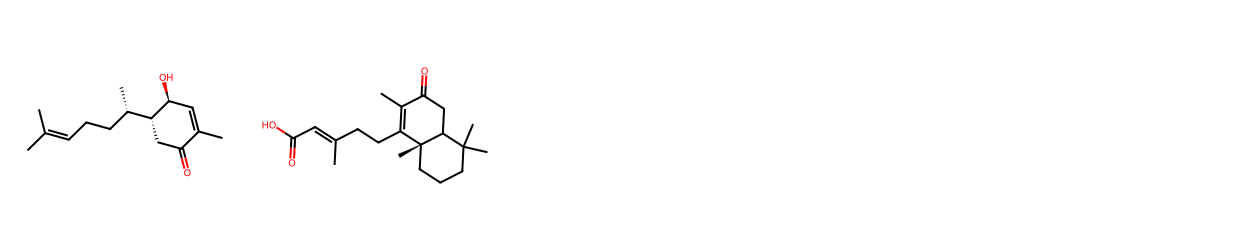
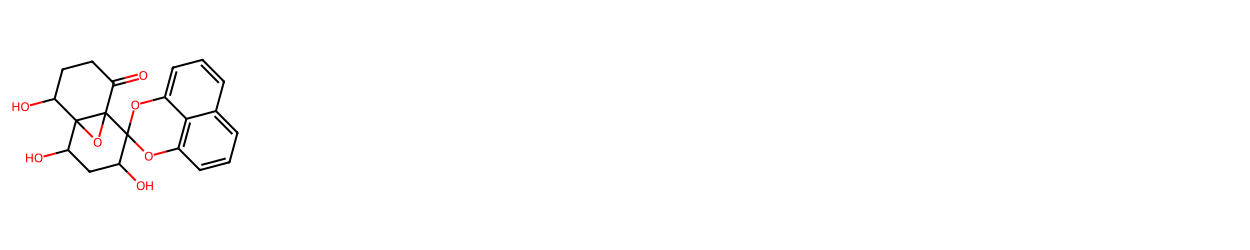
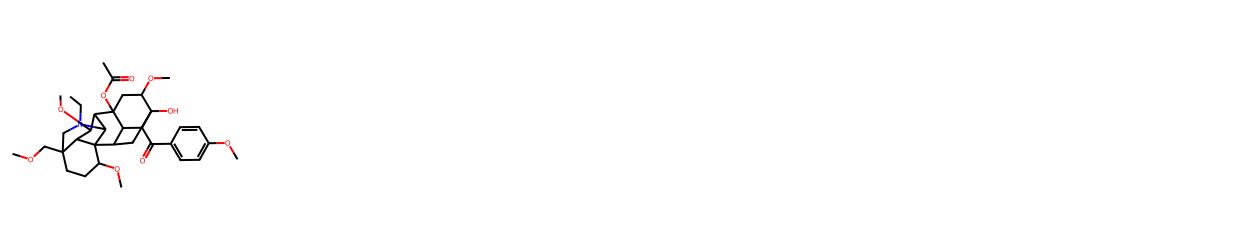
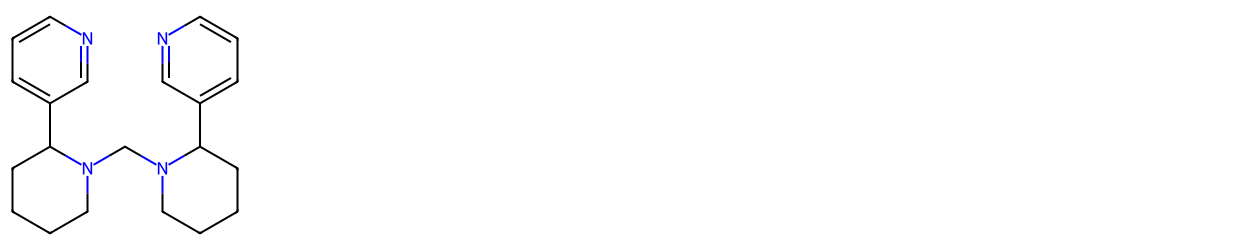
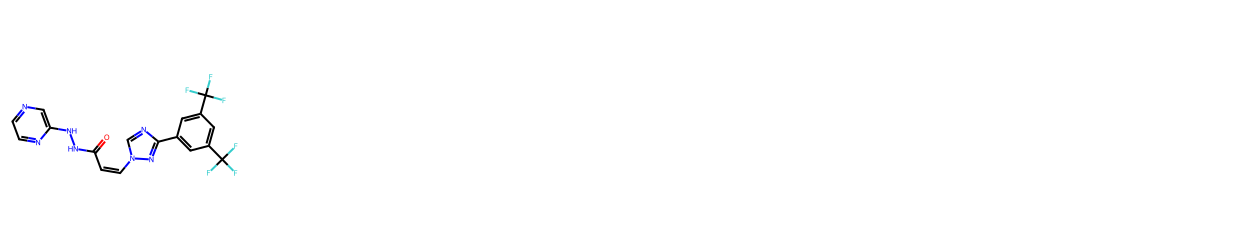
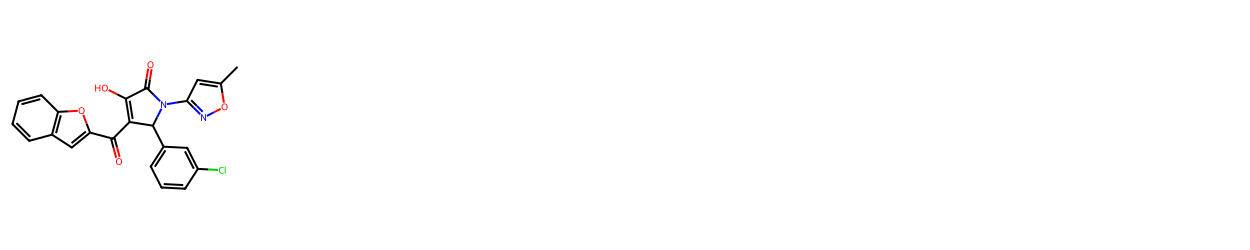
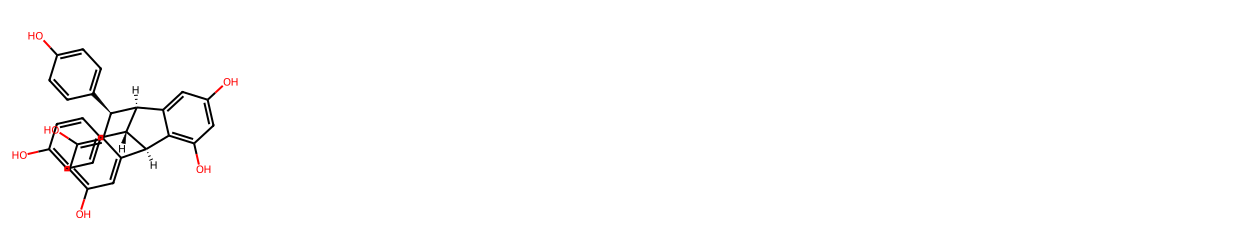
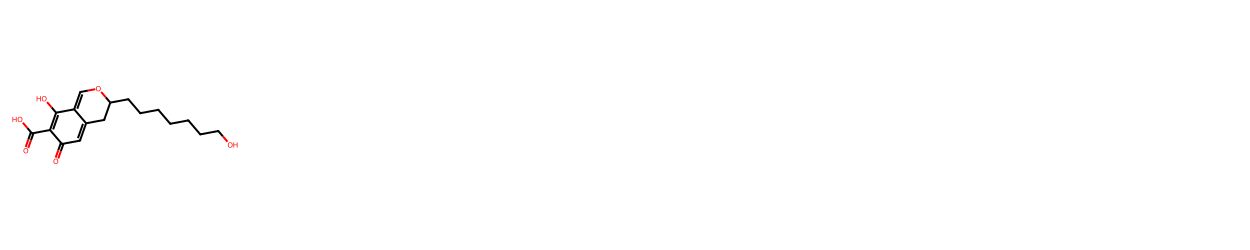
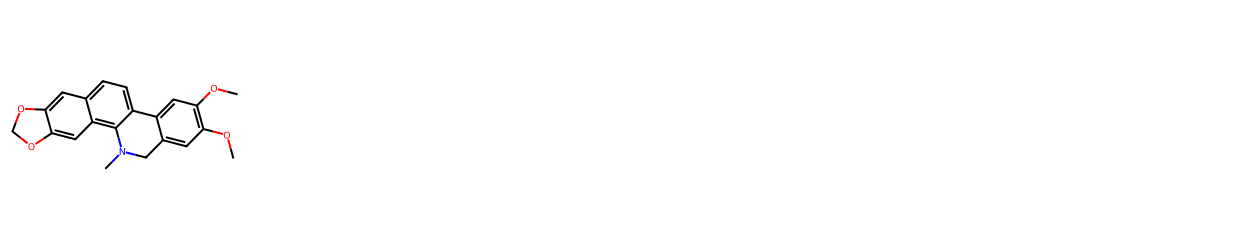
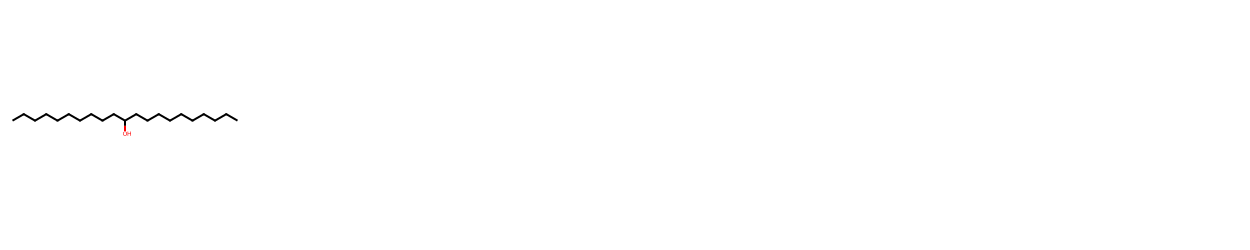
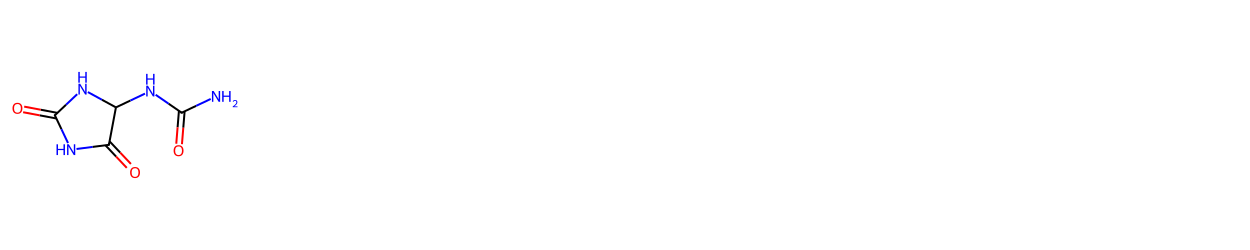
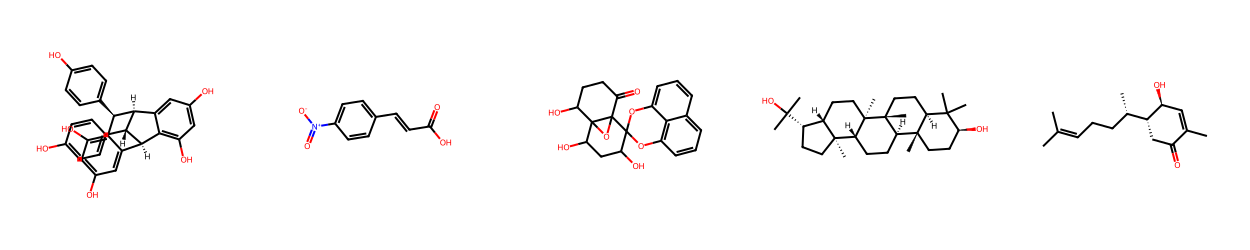
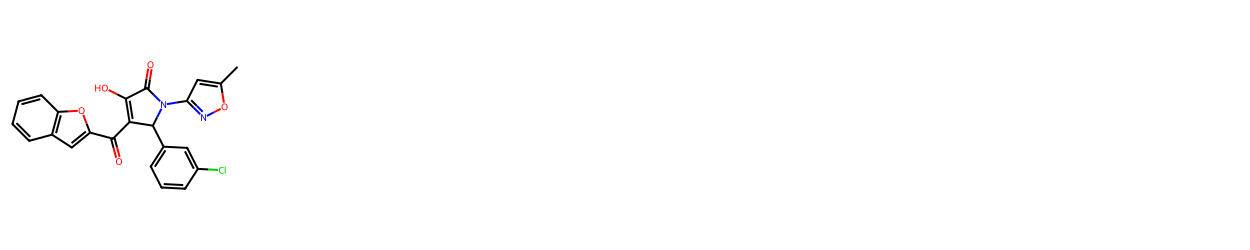
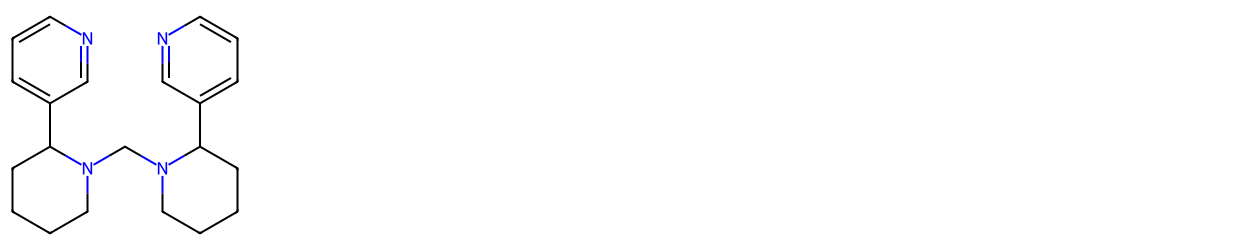
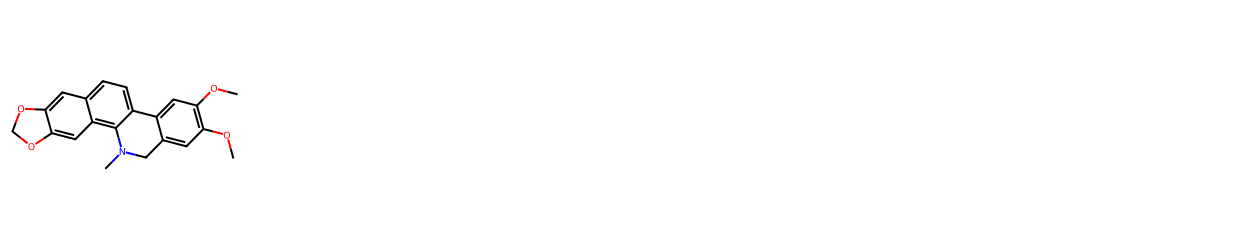
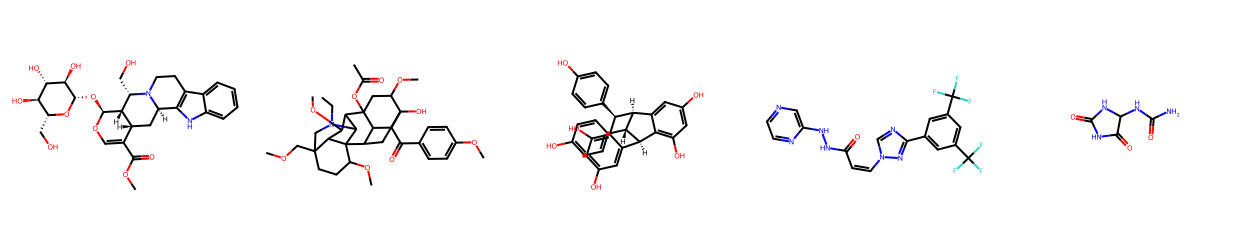

In [18]:
cluster_connect_vis(smiles, min_size=0, steps = 4)